<a href="https://colab.research.google.com/github/Alchwalch/Deep-Learning-Study/blob/main/Image%20Detection/ResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

논문 취지와 맞게 B형태 (차원 조정시에서만 shortcut에서 convolution) 로 함

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Subset,DataLoader,random_split
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
class PCAColorAugmentation:
    def __init__(self, eigenvectors, eigenvalues, std=0.1):
        self.eigenvectors = eigenvectors
        self.eigenvalues = eigenvalues
        self.std = std

    def __call__(self, img):
        img = img.permute(1, 2, 0)
        alphas = torch.normal(0, self.std, size=(3,))
        delta = self.eigenvectors @ (alphas * self.eigenvalues)
        img = (img + delta).clamp(0, 1)
        return img.permute(2, 0, 1)

In [ ]:
def compute_pca(dataset, n_samples=10000):
    loader = DataLoader(dataset, batch_size=n_samples, shuffle=True)
    imgs, _ = next(iter(loader))
    pixels = imgs.permute(0,2,3,1).reshape(-1, 3)
    cov = torch.cov(pixels.T)
    eigenvalues, eigenvectors = torch.linalg.eigh(cov)
    return eigenvectors, eigenvalues

# Model Architecture

## VGGNet

In [ ]:
VGG_types={
    'VGG11':[64,'M',128,'M',256,256,'M',512,512,'M',512,512,'M'],
    'VGG13':[64,64,'M',128,128,'M',256,256,'M',512,512,'M',512,512,'M'],
    'VGG16':[64,64,'M',128,128,'M',256,256,256,'M',512,512,512,'M',512,512,512,'M'],
    'VGG19':[64,64,'M',128,128,'M',256,256,256,256,'M',512,512,512,512,'M',512,512,512,512,'M']
}

class VGG_net(nn.Module):
  def __init__(self,model,in_channels=3,num_classes=10, img_size=32):
    super(VGG_net,self).__init__()
    self.in_channels=in_channels
    self.conv_layers=self.create_conv_layers(VGG_types[model])


    self.fully_connected=nn.Sequential(
        nn.Linear(512*7*7,4096),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(4096,4096),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(4096,num_classes)
    )

  def forward(self,x):
    x=self.conv_layers(x)
    x=x.reshape(x.shape[0],-1)
    x=self.fully_connected(x)
    return x


  def create_conv_layers(self,architecture):
    layers=[]

    in_channels=self.in_channels
    for x in architecture:
      if type(x)==int:
        out_channels=x

        layers+=[
            nn.Conv2d(in_channels=in_channels,out_channels=out_channels,kernel_size=(3,3),stride=(1,1),padding=(1,1)),
            nn.BatchNorm2d(x),
            nn.ReLU()
        ]

        in_channels=x

      else:
        layers+=[nn.MaxPool2d(kernel_size=(2,2),stride=(2,2))]

    return nn.Sequential(*layers)


## ResNet

identity_downsample이 None이면 PlainNet임
아니면 Resnet

In [ ]:
class BasicBlock(nn.Module):
  expansion=1
  def __init__(self,in_channels,out_channels,identity_downsample=None,stride=1):
    super(BasicBlock,self).__init__()
    self.identity_downsample=identity_downsample
    self.residual=nn.Sequential(
        nn.Conv2d(in_channels=in_channels,out_channels=out_channels,kernel_size=3,stride=stride,padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        nn.Conv2d(in_channels=out_channels,out_channels=out_channels*BasicBlock.expansion,kernel_size=3,stride=1,padding=1),
        nn.BatchNorm2d(out_channels*BasicBlock.expansion)
    )

    self.relu=nn.ReLU()

  def forward(self,x):
    identity=x
    x=self.residual(x)
    if self.identity_downsample is not None:
      identity=self.identity_downsample(identity)
      x+=identity
    x=self.relu(x)

    return x

In [ ]:
class BottleNeck(nn.Module):
  expansion=4
  def __init__(self,in_channels,out_channels,identity_downsample=None,stride=1):
    super(BottleNeck,self).__init__()
    self.identity_downsample=identity_downsample
    self.residual=nn.Sequential(
        nn.Conv2d(in_channels=in_channels,out_channels=out_channels,kernel_size=1,stride=1,padding=0),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        nn.Conv2d(in_channels=out_channels,out_channels=out_channels,kernel_size=3,stride=stride,padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        nn.Conv2d(in_channels=out_channels,out_channels=out_channels*BottleNeck.expansion,kernel_size=1,stride=1,padding=0),
        nn.BatchNorm2d(out_channels*BottleNeck.expansion)
    )

    self.relu=nn.ReLU()

  def forward(self,x):
    identity=x
    x=self.residual(x)
    if self.identity_downsample is not None:
      identity=self.identity_downsample(identity)
      x+=identity
    x=self.relu(x)

    return x

In [ ]:
class ResNet(nn.Module):
  def __init__(self,block,layers,image_channels=3,num_classes=10):
    super(ResNet,self).__init__()
    self.in_channels=64
    self.conv1=nn.Sequential(
        nn.Conv2d(in_channels=image_channels,out_channels=64,kernel_size=7,stride=2,padding=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3,stride=2,padding=1)
    )

    self.conv2=self._make_layer(block,layers[0],out_channels=64,stride=1)
    self.conv3=self._make_layer(block,layers[1],out_channels=128,stride=2)
    self.conv4=self._make_layer(block,layers[2],out_channels=256,stride=2)
    self.conv5=self._make_layer(block,layers[3],out_channels=512,stride=2)

    self.avgpool=nn.AdaptiveAvgPool2d((1,1))
    self.fc=nn.Linear(512*block.expansion,num_classes)

  def forward(self,x):
    x=self.conv1(x)
    x=self.conv2(x)
    x=self.conv3(x)
    x=self.conv4(x)
    x=self.conv5(x)
    x=self.avgpool(x)
    x=x.reshape(x.shape[0],-1)
    x=self.fc(x)

    return x

  def _make_layer(self,block,num_residual_blocks,out_channels,stride):
    strides = [stride] + [1] * (num_residual_blocks - 1)
    layers=[]

    for stride in strides:

      identity_downsample=nn.Sequential()
      expansion=block.expansion

      if stride!=1 or self.in_channels!=out_channels*expansion:
        identity_downsample=nn.Sequential(
            nn.Conv2d(in_channels=self.in_channels,out_channels=out_channels*expansion,kernel_size=1,stride=stride),
            nn.BatchNorm2d(out_channels*expansion)
        )

      layers.append(block(self.in_channels,out_channels,identity_downsample,stride))
      self.in_channels=out_channels*expansion

    return nn.Sequential(*layers)

In [ ]:
def resnet18():
    return ResNet(BasicBlock, [2,2,2,2])

def resnet34():
    return ResNet(BasicBlock, [3,4,6,3])

def resnet50():
    return ResNet(BottleNeck, [3,4,6,3])

def resnet101():
    return ResNet(BottleNeck, [3,4,23,3])

def resnet152():
    return ResNet(BottleNeck, [3,8,36,3])

##Plain Net

In [ ]:
class PlainNet(nn.Module):
  def __init__(self,block,layers,image_channels=3,num_classes=10):
    super(PlainNet,self).__init__()
    self.in_channels=64
    self.conv1=nn.Sequential(
        nn.Conv2d(in_channels=image_channels,out_channels=64,kernel_size=7,stride=2,padding=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3,stride=2,padding=1)
    )

    self.conv2=self._make_layer(block,layers[0],out_channels=64,stride=1)
    self.conv3=self._make_layer(block,layers[1],out_channels=128,stride=2)
    self.conv4=self._make_layer(block,layers[2],out_channels=256,stride=2)
    self.conv5=self._make_layer(block,layers[3],out_channels=512,stride=2)

    self.avgpool=nn.AdaptiveAvgPool2d((1,1))
    self.fc=nn.Linear(512*block.expansion,num_classes)

  def forward(self,x):
    x=self.conv1(x)
    x=self.conv2(x)
    x=self.conv3(x)
    x=self.conv4(x)
    x=self.conv5(x)
    x=self.avgpool(x)
    x=x.reshape(x.shape[0],-1)
    x=self.fc(x)

    return x

  def _make_layer(self,block,num_residual_blocks,out_channels,stride):
    strides = [stride] + [1] * (num_residual_blocks - 1)
    layers=[]

    for stride in strides:

      identity_downsample=None
      expansion=block.expansion

      layers.append(block(self.in_channels,out_channels,identity_downsample,stride))
      self.in_channels=out_channels*expansion

    return nn.Sequential(*layers)

In [ ]:
def plainnet18():
    return PlainNet(BasicBlock, [2,2,2,2])

def plainnet34():
    return PlainNet(BasicBlock, [3,4,6,3])

def plainnet50():
    return PlainNet(BottleNeck, [3,4,6,3])

def plainnet101():
    return PlainNet(BottleNeck, [3,4,23,3])

def plainnet152():
    return PlainNet(BottleNeck, [3,8,36,3])

# Testing 1 (Comparing training error)

In [ ]:
#%%script echo skip

epochs=50
start_epoch=0
learning_rate=1e-1
batch_size=32
patience = 5
device='cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
#%%script echo skip

raw_train_dataset = datasets.STL10(root='/content/drive/MyDrive/data', split='train', download=True, transform=transforms.ToTensor())
eigenvectors, eigenvalues = compute_pca(raw_train_dataset)

transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    PCAColorAugmentation(eigenvectors, eigenvalues, std=0.1),
])

train_dataset = datasets.STL10(root='/content/drive/MyDrive/data', split='train', download=True, transform=transform_train)

#블로그 리뷰용 시드 고정
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(train_dataset, [4000, 1000], generator=generator)


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
%%script echo skip

# Gemini 도움 받음

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

base_train_dataset = datasets.CIFAR10(root='/data', train=True, download=True)

# 블로그 리뷰용 시드 고정 및 인덱스 분할
generator = torch.Generator().manual_seed(42)
train_size = 40000
val_size = 10000

train_indices, val_indices = random_split(range(len(base_train_dataset)), [train_size, val_size], generator=generator)

class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __getitem__(self, idx):
        img, target = self.dataset[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, target

    def __len__(self):
        return len(self.indices)

train_dataset = TransformedSubset(base_train_dataset, train_indices, transform_train)
val_dataset = TransformedSubset(base_train_dataset, val_indices, transform_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

skip


In [ ]:
#%%script echo skip

models = {
    'plain18': plainnet18().to(device),
    'plain34': plainnet34().to(device),
    'resnet18': resnet18().to(device),
    'resnet34': resnet34().to(device)
}

optimizers = {name: optim.SGD(model.parameters(),lr=learning_rate,momentum=0.9,weight_decay=1e-4) for name, model in models.items()}
schedulers = {name: optim.lr_scheduler.ReduceLROnPlateau(optimizers[name], mode='min', patience=3, factor=0.1) for name in models}
criterion = nn.CrossEntropyLoss()

In [ ]:
#%%script echo skip
best_losses={name: float('inf') for name in models}
no_improves = {name: 0 for name in models}
stopped = set()
train_loss_lists = {name: [] for name in models}
val_loss_lists = {name: [] for name in models}

In [ ]:
%%script echo skip
start_epoch=epochs
for name, model in models.items():
    path = f'/content/drive/MyDrive/resnet1_{name}.pth'
    if os.path.exists(path):
        checkpoint = torch.load(path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizers[name].load_state_dict(checkpoint['optimizer_state_dict'])
        schedulers[name].load_state_dict(checkpoint['scheduler_state_dict'])
        train_loss_lists[name] = checkpoint['train_loss_list']
        val_loss_lists[name] = checkpoint['val_loss_list']
        best_losses[name] = checkpoint['best_loss']
        start_epoch = min(start_epoch,checkpoint['epoch']+1)

skip


In [ ]:
#%%script echo skip

for epoch in tqdm(range(start_epoch, epochs), desc="Epoch"):

    for name, model in models.items():
        if name in stopped:
            continue

        train_loss = 0.0
        val_loss = 0.0

        model.train()
        for x, t in tqdm(train_loader, desc=f"{name} Iteration", leave=False):
            x, t = x.to(device), t.to(device)
            optimizers[name].zero_grad()
            loss = criterion(model(x), t)
            train_loss += loss.item()
            loss.backward()
            optimizers[name].step()

        model.eval()
        with torch.no_grad():
            for x, t in val_loader:
                x, t = x.to(device), t.to(device)
                val_loss += criterion(model(x), t).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        train_loss_lists[name].append(train_loss)
        val_loss_lists[name].append(val_loss)

        schedulers[name].step(val_loss)

        if val_loss < best_losses[name]:
            best_losses[name] = val_loss
            no_improves[name] = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizers[name].state_dict(),
                'scheduler_state_dict': schedulers[name].state_dict(),
                'best_loss': best_losses[name],
                'train_loss_list': train_loss_lists[name],
                'val_loss_list': val_loss_lists[name],
                'epoch': epoch
            }, f'/content/drive/MyDrive/resnet1_{name}.pth')
        else:
            no_improves[name] += 1
            if no_improves[name] >= patience:
                print(f"Early Stopping {name} at Epoch {epoch+1}")
                stopped.add(name)

    print(f'Epoch {epoch+1} | ' + ' | '.join(
        f'{name} Loss: {train_loss_lists[name][-1]:.4f}'
        for name in models if train_loss_lists[name]
    ))

    if len(stopped) == len(models):
        break

Epoch:   0%|          | 0/50 [00:00<?, ?it/s]

plain18 Iteration:   0%|          | 0/125 [00:00<?, ?it/s]

plain34 Iteration:   0%|          | 0/125 [00:00<?, ?it/s]

resnet18 Iteration:   0%|          | 0/125 [00:00<?, ?it/s]

resnet34 Iteration:   0%|          | 0/125 [00:00<?, ?it/s]

...

Epoch 15 | plain18 Loss: 1.4519 | plain34 Loss: 1.7601 | resnet18 Loss: 1.2273 | resnet34 Loss: 1.3909


plain18 Iteration:   0%|          | 0/125 [00:00<?, ?it/s]

plain34 Iteration:   0%|          | 0/125 [00:00<?, ?it/s]

resnet18 Iteration:   0%|          | 0/125 [00:00<?, ?it/s]

KeyboardInterrupt: 

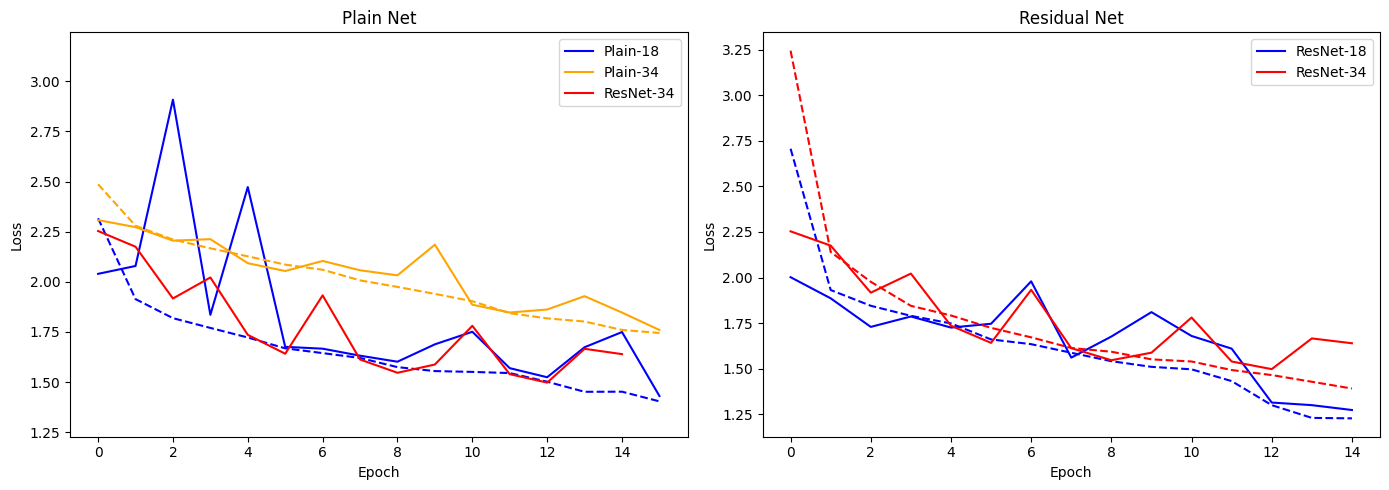

In [ ]:
#%%script echo skip

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

all_losses = (train_loss_lists['plain18'] + val_loss_lists['plain18'] +
              train_loss_lists['plain34'] + val_loss_lists['plain34'] +
              train_loss_lists['resnet18'] + val_loss_lists['resnet18'] +
              train_loss_lists['resnet34'] + val_loss_lists['resnet34'])

ymin, ymax = min(all_losses), max(all_losses)
axes[0].set_ylim(ymin, ymax)

axes[0].plot(train_loss_lists['plain18'], color='blue', linestyle='--')
axes[0].plot(val_loss_lists['plain18'], label='Plain-18', color='blue', linestyle='-')
axes[0].plot(train_loss_lists['plain34'], color='orange', linestyle='--')
axes[0].plot(val_loss_lists['plain34'], label='Plain-34', color='orange', linestyle='-')
axes[0].plot(val_loss_lists['resnet34'], label='ResNet-34', color='red')
axes[0].set_title("Plain Net")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(train_loss_lists['resnet18'], color='blue', linestyle='--')
axes[1].plot(val_loss_lists['resnet18'], label='ResNet-18', color='blue', linestyle='-')
axes[1].plot(train_loss_lists['resnet34'], color='red', linestyle='--')
axes[1].plot(val_loss_lists['resnet34'], label='ResNet-34', color='red', linestyle='-')
axes[1].set_title("Residual Net")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

Adam optimizer 쓴 결과+ Resnet18이 resnet34보다 loss가 낮았던 이유
- 에포크 10임 아직
- adamoptimizer 사용-> 너무 작은 lr

Gemini 曰 앞서 원인으로 지목했던 Adam(lr=0.001)은 현재 데이터셋이나 환경 대비 지나치게 과격하고 큰 학습률입니다. 파라미터 수가 적은 ResNet-18은 그나마 거친 환경에서도 어떻게든 길을 찾아 내려가지만, 파라미터 수가 2배나 많고 최적화해야 할 차원이 훨씬 높은 ResNet-34는 큰 학습률의 타격을 직격타로 맞게 됩니다.

즉, 나침반(학습률)이 고장 난 상태에서는 지도(파라미터 공간)가 넓고 복잡할수록 길을 찾기가 훨씬 더 어려워져서 Loss가 더 높게 치솟는 것입니다.

얕은 레이어에서는 초기 수렴이 있음

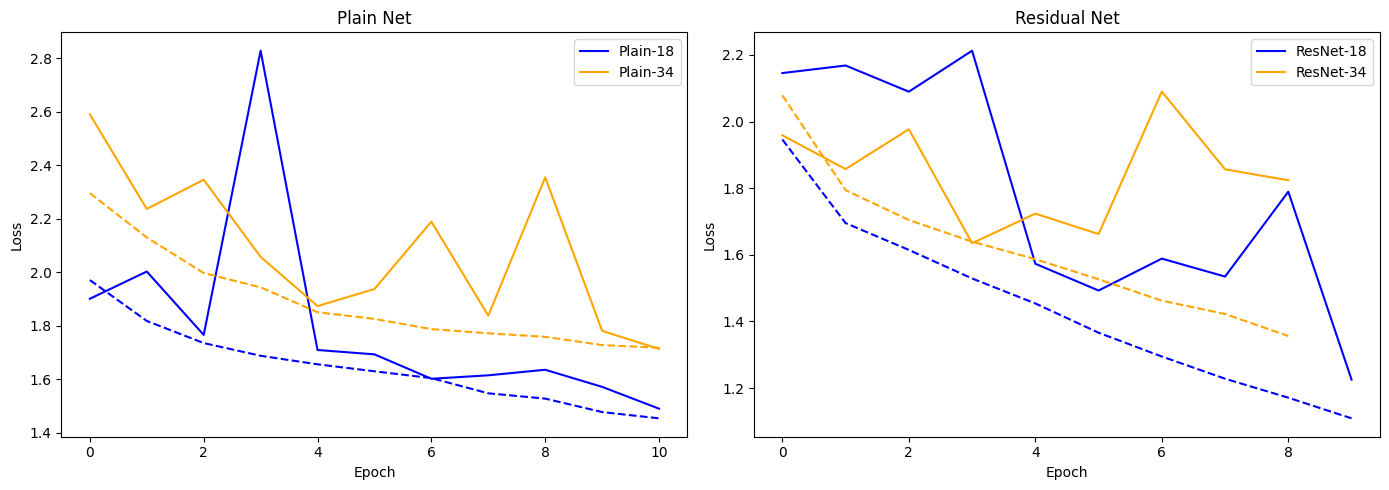

STL10 SGD옵티마이저
train은 괜찮 validation 이상함

걍 STL10이 너무 작음

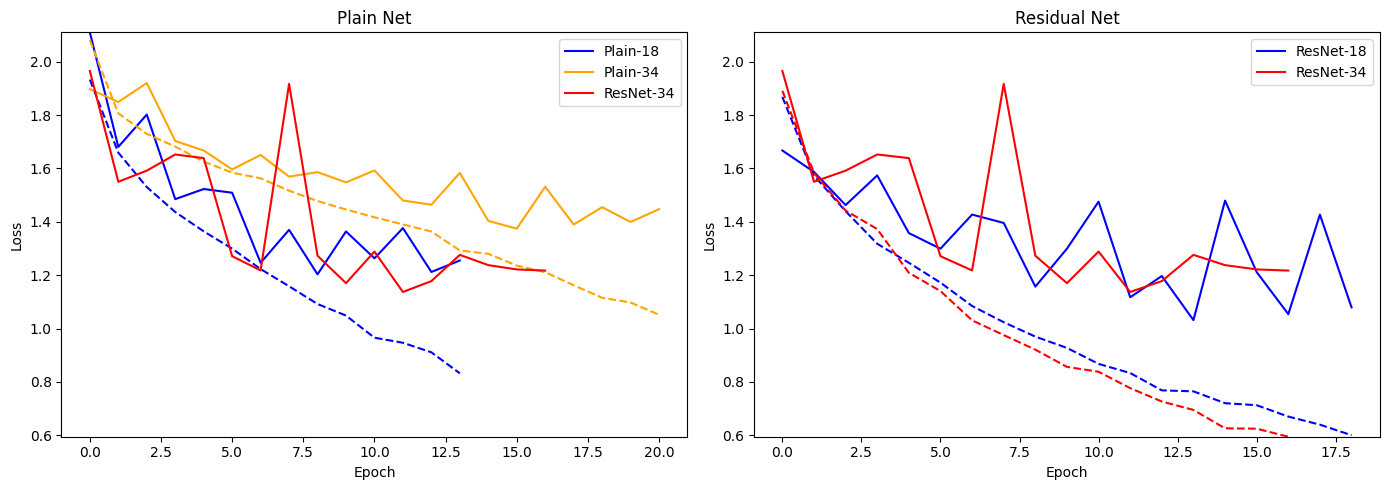

CIFAR10 결과

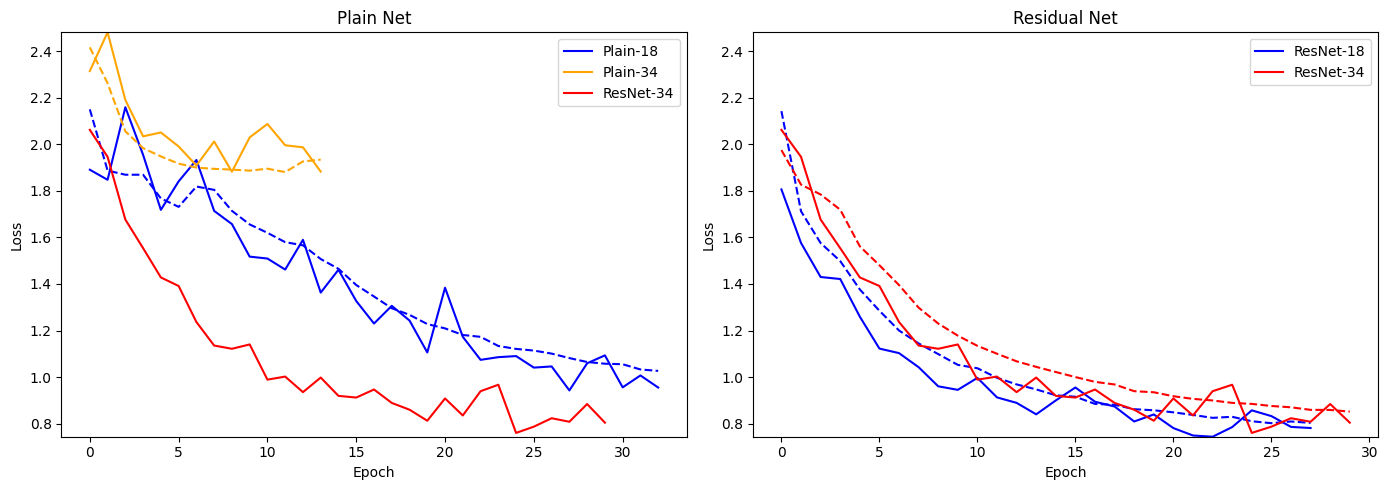

#Testing2

In [ ]:
%%script echo skip

epochs=50
learning_rate=1e-1
batch_size=16
patience = 5
device='cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
%%script echo skip
raw_train_dataset = datasets.STL10(root='/content/drive/MyDrive/data', split='train', download=True, transform=transforms.ToTensor())
eigenvectors, eigenvalues = compute_pca(raw_train_dataset)

transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    PCAColorAugmentation(eigenvectors, eigenvalues, std=0.1),
])

transform_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

train_dataset = datasets.STL10(root='/content/drive/MyDrive/data', split='train', download=True, transform=transform_train)
test_dataset = datasets.STL10(root='/content/drive/MyDrive/data', split='test', download=True, transform=transform_test)

#블로그 리뷰용 시드 고정
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(train_dataset, [4000, 1000], generator=generator)
test_subset = Subset(test_dataset, range(1000))

In [ ]:
#%%script echo skip
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

In [ ]:
%%script echo skip

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

base_train_dataset = datasets.CIFAR10(root='/data', train=True, download=True)
base_test_dataset = datasets.CIFAR10(root='/data', train=False, download=True)


generator = torch.Generator().manual_seed(42)
train_size = 40000
val_size = 10000

train_indices, val_indices = random_split(range(len(base_train_dataset)), [train_size, val_size], generator=generator)


class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __getitem__(self, idx):
        img, target = self.dataset[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, target

    def __len__(self):
        return len(self.indices)


train_dataset = TransformedSubset(base_train_dataset, train_indices, transform_train)
val_dataset = TransformedSubset(base_train_dataset, val_indices, transform_val)


test_dataset = TransformedSubset(base_test_dataset, range(len(base_test_dataset)), transform_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
%%script echo skip
models = {
    'vgg16': VGG_net('VGG16').to(device),
    'resnet50': resnet50().to(device)
}

optimizers={
  'vgg16' : optim.SGD(models['vgg16'].parameters(),lr=1e-2,momentum=0.9,weight_decay=5e-4),
  'resnet50' : optim.SGD(models['resnet50'].parameters(),lr=1e-1,momentum=0.9,weight_decay=1e-4)
}
schedulers = {name: optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1) for name, optimizer in optimizers.items()}
criterion = nn.CrossEntropyLoss()

In [ ]:
%%script echo skip
start_epochs = {name: 0 for name in models.keys()}
best_losses={name: float('inf') for name in models}
no_improves = {name: 0 for name in models}
stopped = set()
train_loss_lists = {name: [] for name in models}
val_loss_lists = {name: [] for name in models}
test_acc_lists = {name: [] for name in models}

In [ ]:
%%script echo skip

for name, model in models.items():
    path = f'/content/drive/MyDrive/resnet2_{name}.pth'
    if os.path.exists(path):
        checkpoint = torch.load(path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizers[name].load_state_dict(checkpoint['optimizer_state_dict'])
        schedulers[name].load_state_dict(checkpoint['scheduler_state_dict'])
        train_loss_lists[name] = checkpoint['train_loss_list']
        val_loss_lists[name] = checkpoint['val_loss_list']
        best_losses[name] = checkpoint['best_loss']
        start_epochs[name] = checkpoint['epoch'] + 1

In [ ]:
%%script echo skip

for epoch in tqdm(range(epochs), desc="Epoch"):

    for name, model in models.items():
        if name in stopped:
            continue

        if epoch < start_epochs[name]:
            continue

        train_loss = 0.0
        val_loss = 0.0
        test_acc=0.0

        model.train()
        for x, t in tqdm(train_loader, desc=f"{name} Iteration", leave=False):
            x, t = x.to(device), t.to(device)
            optimizers[name].zero_grad()
            loss = criterion(model(x), t)
            train_loss += loss.item()
            loss.backward()
            optimizers[name].step()

        model.eval()
        with torch.no_grad():
            for x, t in val_loader:
                x, t = x.to(device), t.to(device)
                val_loss += criterion(model(x), t).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        train_loss_lists[name].append(train_loss)
        val_loss_lists[name].append(val_loss)

        schedulers[name].step(val_loss)

        if val_loss < best_losses[name]:
            best_losses[name] = val_loss
            no_improves[name] = 0

            with torch.no_grad():
              for x, t in test_loader:
                  x, t = x.to(device), t.to(device)
                  output = model(x)
                  test_acc += (output.argmax(1) == t).sum().item()

            test_acc /= len(test_loader.dataset)
            test_acc_lists[name].append(test_acc)

            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizers[name].state_dict(),
                'scheduler_state_dict': schedulers[name].state_dict(),
                'best_loss': best_losses[name],
                'train_loss_list': train_loss_lists[name],
                'val_loss_list': val_loss_lists[name],
                'test_acc_list': test_acc_lists[name],
                'epoch': epoch
            }, f'/content/drive/MyDrive/resnet2_{name}.pth')
        else:
            no_improves[name] += 1
            if no_improves[name] >= patience:
                print(f"Early Stopping {name} at Epoch {epoch+1}")
                stopped.add(name)

            test_acc_lists[name].append(-1)

    print(f'Epoch {epoch+1} | ' + ' | '.join(
        f'{name} Loss: {train_loss_lists[name][-1]:.4f}'
        for name in models if train_loss_lists[name]
    ))

    if len(stopped) == len(models):
        break

In [ ]:
%%script echo skip

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_ylim(1,4)
axes[0].plot(train_loss_lists['vgg16'], color='blue', linestyle='--')
axes[0].plot(val_loss_lists['vgg16'], label='vgg16', color='blue', linestyle='-')
axes[0].plot(train_loss_lists['resnet50'], color='orange', linestyle='--')
axes[0].plot(val_loss_lists['resnet50'], label='resnet50', color='orange', linestyle='-')
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

for name in models.keys():
    if test_acc_lists[name]:
        raw_acc_list = test_acc_lists[name]

        valid_epochs = [epoch for epoch, acc in enumerate(raw_acc_list) if acc != -1]
        valid_accs = [acc for acc in raw_acc_list if acc != -1]

        if valid_accs:
            axes[1].plot(valid_epochs, valid_accs, linestyle='-', marker='o', label=f'{name} Test Acc')

axes[1].set_title("Test Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

CIFAR10일때는 vggnet에서 fclayer로 넘어가는 부분을 7x7x512 대신에 1x1x512로 했음

밑에 둘 다 scheduler 의 patience=10으로 해버려서 학습률 조정이 안 됨

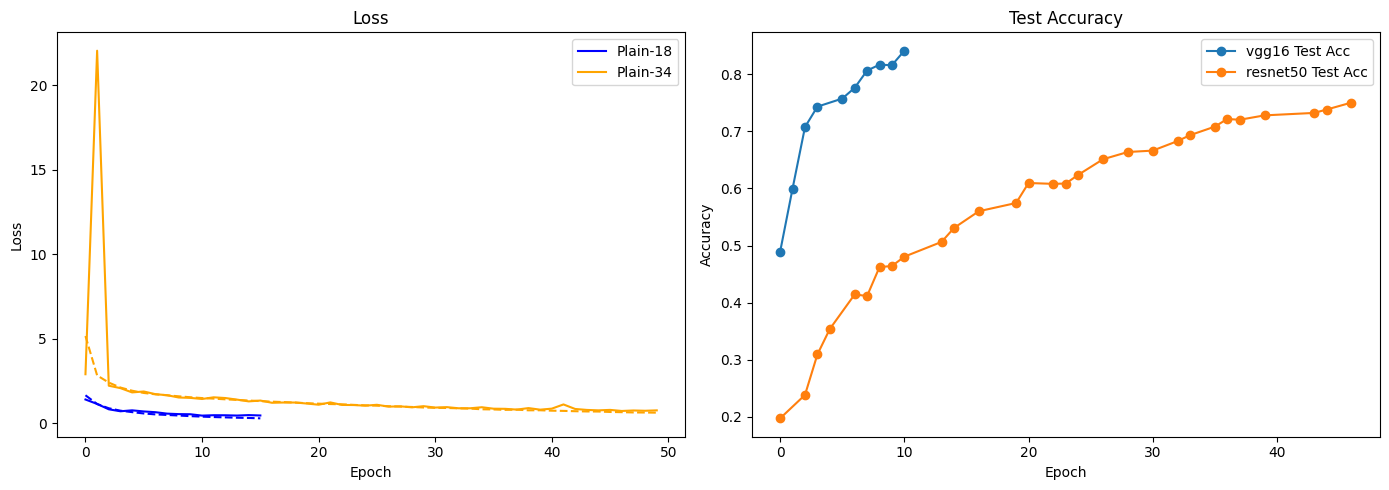

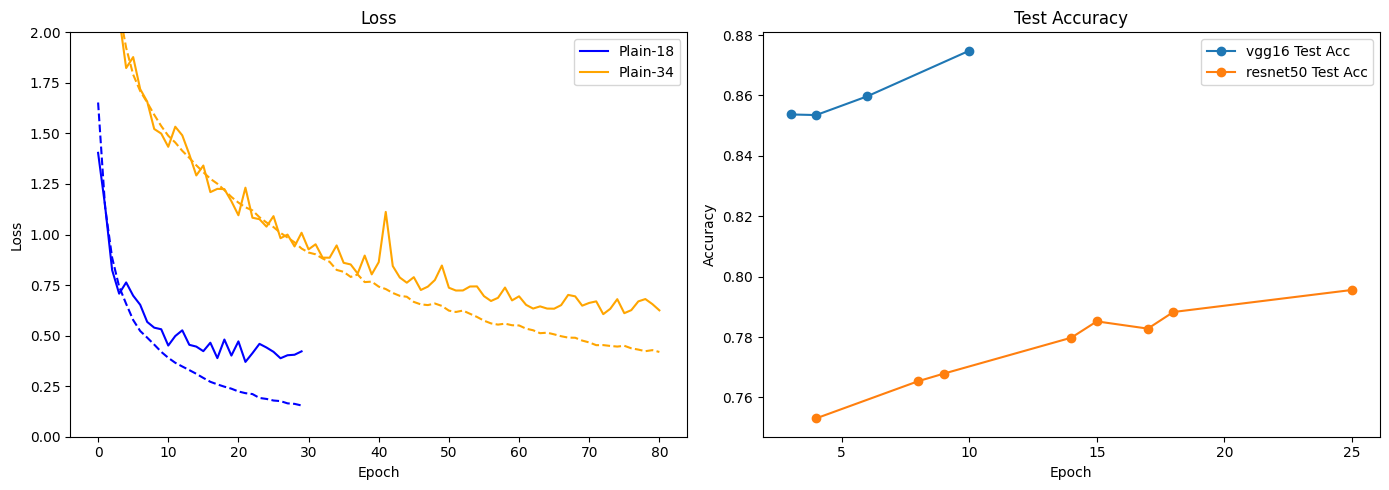

스케줄러 조정 뒤 (변함 x)

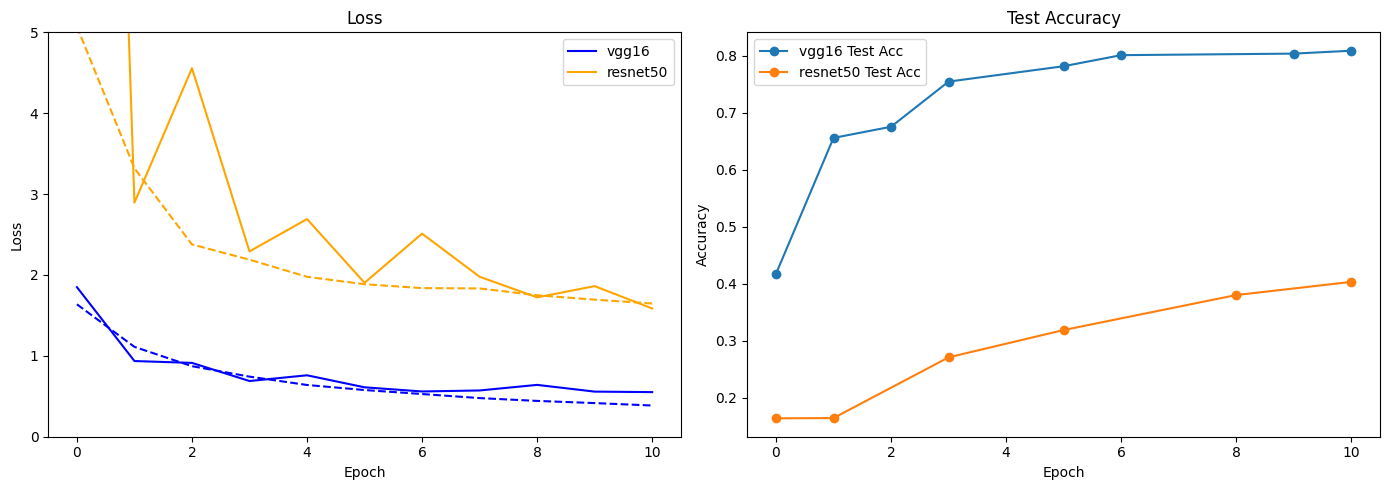

 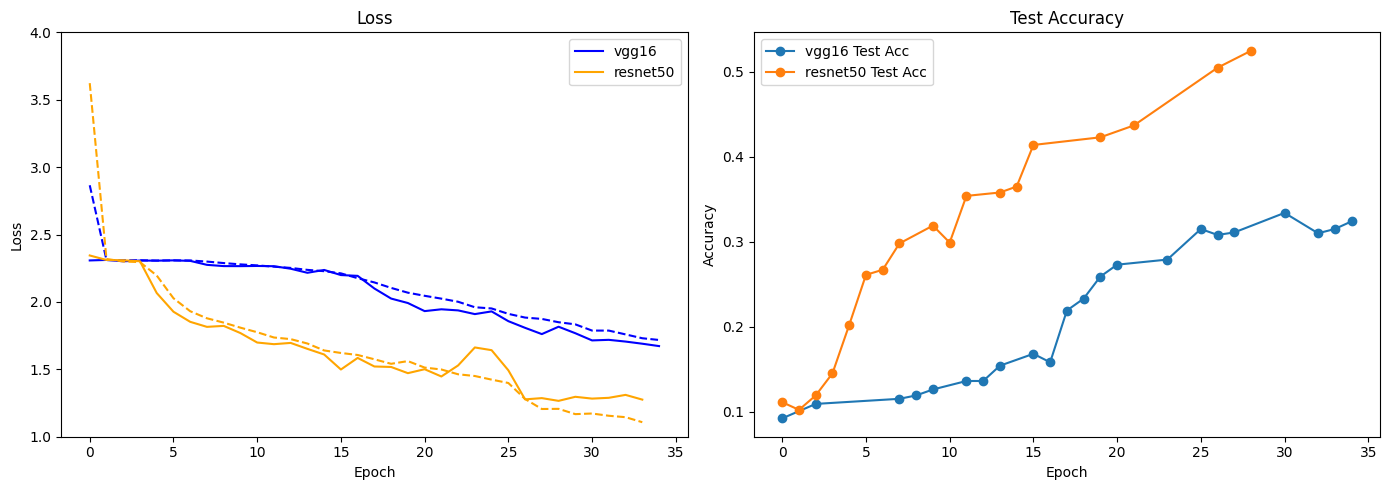